In [26]:
source("./src/slingshot_functions.r")
library(qs)

In [2]:
seurat_obj <- qread("../Data/out/seurat_phase2_annotated.qs")

In [3]:
eurat_obj <- SetIdent(seurat_obj, value="cell_label")

In [4]:
table(seurat_obj@meta.data$cell_label, seurat_obj@meta.data$orig.ident)

                     
                      SEG0503 SEG0504 SEG0505
  Cycling                8811    5427    5485
  Progenitor-like        1690    2332    7853
  PAX3-FOXO1-specific    1742     469     465
  Differentiated          246     486     526

In [5]:
Idents(seurat_obj) <- "cell_label"

In [6]:
singlecell_obj <- as.SingleCellExperiment(seurat_obj, assay='RNA')

In [7]:
singlecell_obj

class: SingleCellExperiment 
dim: 23016 35532 
metadata(0):
assays(2): counts logcounts
rownames(23016): AL627309.5 LINC01409 ... RAB39B FAM197Y6
rowData names(0):
colnames(35532): SEG0503_SEG503_AAACCCAAGAAGTCAT-1
  SEG0503_SEG503_AAACCCAAGGAATCGC-1 ...
  SEG0505_SEG505_TTTGTTGTCGGTCTGG-1 SEG0505_SEG505_TTTGTTGTCGTAGTGT-1
colData names(49): orig.ident nCount_RNA ... AP.1.expressing_Score.1
  ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(0):

In [15]:
options(repr.plot.width = 12, repr.plot.height = 10)
slingshot_obj <- slingshot(singlecell_obj, 
                           clusterLabels    = "cell_label", 
                           reducedDim       = "UMAP", 
                           start.clus       = "Progenitor-like",
                           end.clus       = c("Cycling",'Differentiated'),
                             shrink        = 0.99,
                              extend        = "n",
                              allow.breaks  = TRUE,
                              stretch       = 0.0,
                              thresh        = 0.001
                          )

slingLineages(slingshot_obj)

$Lineage1
[1] "Progenitor-like"     "PAX3-FOXO1-specific" "Cycling"            

$Lineage2
[1] "Progenitor-like"     "PAX3-FOXO1-specific" "Differentiated"

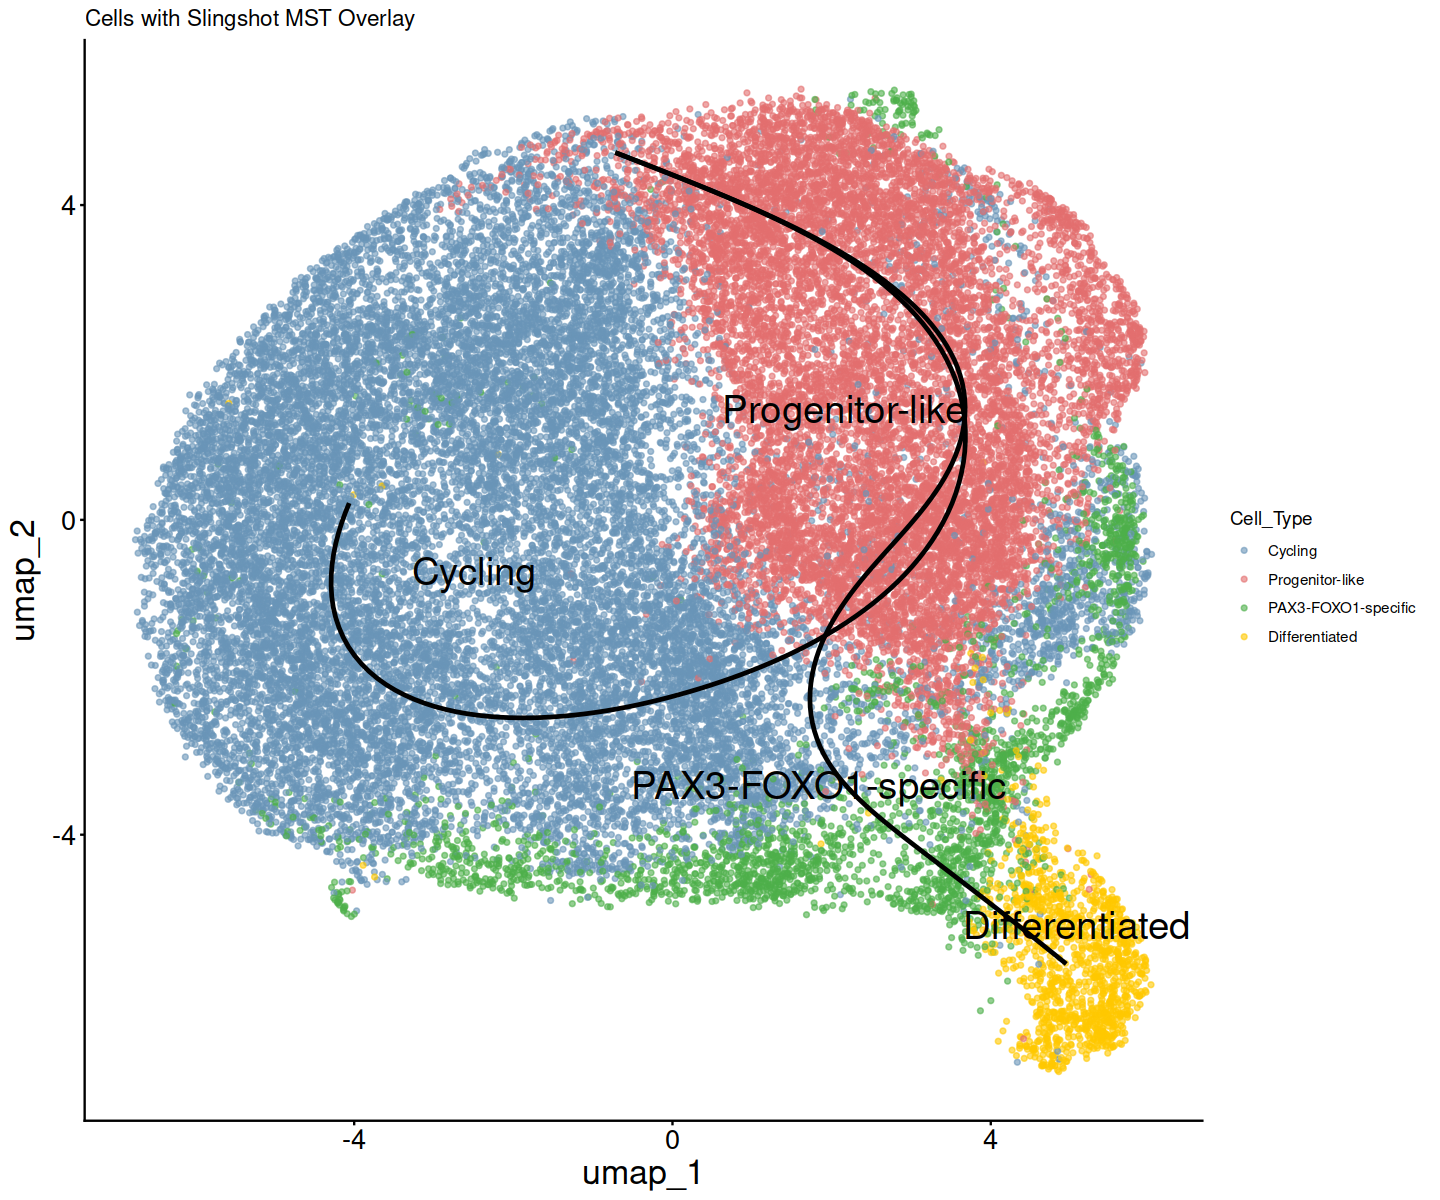

In [29]:
cluster_colors <- c(
  "Progenitor-like" = "#E36f6f",
  "Cycling" = "#6A95B8",
  "PAX3-FOXO1-specific" = "#4DAF4A",
  "Ground-state" = "#984EA3",
  "Differentiated" = "#FFC800"
)

cell_plot <- plot_slingshot_trajectory_trimmed(
  seurat_obj,
  slingshot_obj,
  annot_column = "cell_label",
  cluster_colors = cluster_colors,
  point_size = 1.0,
  point_alpha = 0.6
)

ggsave(
  "./out/slingshot_trajectory_phase2.png",
  plot = cell_plot,
  width = 8,
  height = 6,
  dpi = 300
)

cell_plot

In [17]:
qsave(slingshot_obj, "./out/slingshot_obj_phase2.qs")